In [10]:
%pip install numpy matplotlib pillow

Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [14]:
def compress_block(input_image, num_components): #task 2
    image_shape=input_image.shape
    img_height=image_shape[0]
    img_width=image_shape[1]
    output_image=np.zeros_like(input_image)

    for row_idx in range(0, img_height, 8):  # step through 8x8 blocks
        for col_idx in range(0, img_width, 8):
            current_block=input_image[row_idx:row_idx+8, col_idx:col_idx+8]

            svd_result=np.linalg.svd(current_block,full_matrices=False)
            u_matrix=svd_result[0]
            singular_vals=svd_result[1]
            vt_matrix=svd_result[2]
            top_u=u_matrix[:, :num_components]  # get first k columns
            top_sigma=singular_vals[:num_components]
            top_vt=vt_matrix[:num_components, :]  # get first k rows

            reconstructed_block=top_u @ np.diag(top_sigma) @ top_vt  # rebuild the block by multiplying SVD components back together
            output_image[row_idx:row_idx+8, col_idx:col_idx+8]=reconstructed_block #put block back in image
    return output_image

def compute_reconstruction_error(original_img, reconstructed_img):
    error=np.linalg.norm(original_img-reconstructed_img)
    return error

def compute_compression_ratio(num_components): #task 3
    original_size=64  # 8x8 block
    compressed_size=num_components*17  #from teh 8+8+1
    ratio=original_size / compressed_size
    return ratio

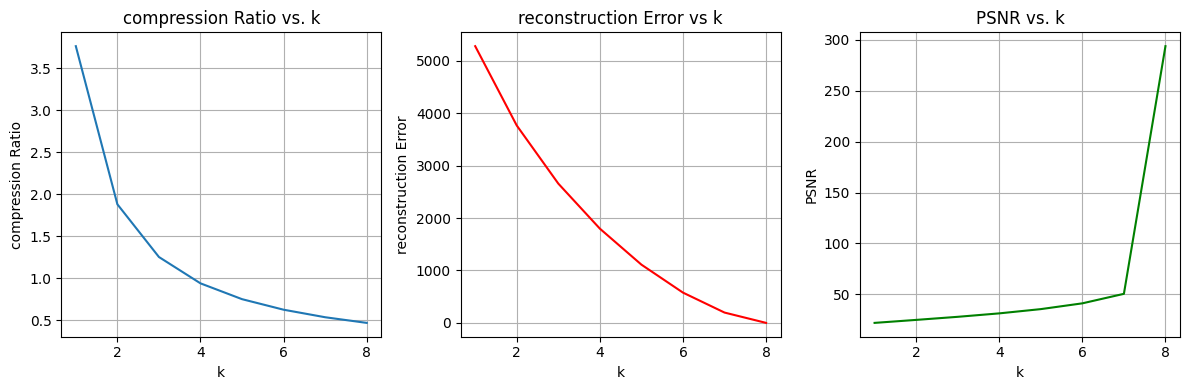

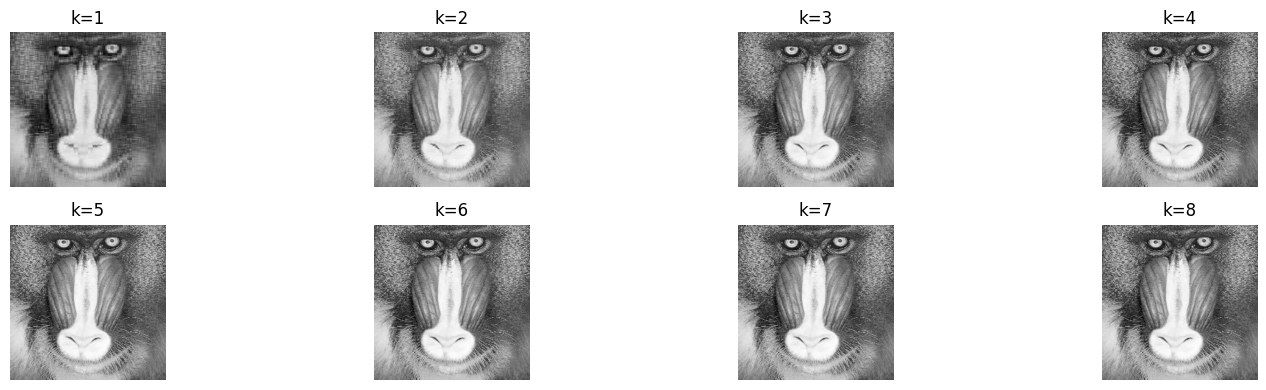

In [15]:
img_path='baboon.jpg'
loaded_img=Image.open(img_path).convert('L')
original_img=np.array(loaded_img,dtype=np.float64)

k_range=list(range(1, 9))  # k from 1 to 8
ratio_list=[]
error_list=[]
psnr_list=[]
compressed_imgs=[]

for k_val in k_range:
    rebuilt_img=compress_block(original_img, k_val)
    current_ratio=compute_compression_ratio(k_val)
    current_error=compute_reconstruction_error(original_img, rebuilt_img)

    mean_squared_error=np.mean((original_img-rebuilt_img)** 2)
    if mean_squared_error == 0:
        current_psnr=float('inf') #perfect reconstruction case
    else:
        max_pixel_val=255.0
        current_psnr=20 * np.log10(max_pixel_val/np.sqrt(mean_squared_error)) #convert mse to decibels

    ratio_list.append(current_ratio)
    error_list.append(current_error)
    psnr_list.append(current_psnr)
    compressed_imgs.append(rebuilt_img)

plt.figure(figsize=(12, 4))#task 4, visualization

plt.subplot(1, 3, 1)
plt.plot(k_range,ratio_list)
plt.xlabel('k')
plt.ylabel('compression Ratio')
plt.title('compression Ratio vs. k')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(k_range,error_list,color='red')
plt.xlabel('k')
plt.ylabel('reconstruction Error')
plt.title('reconstruction Error vs k')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(k_range,psnr_list,color='green')
plt.xlabel('k')
plt.ylabel('PSNR')
plt.title('PSNR vs. k')
plt.grid(True)
plt.tight_layout()
plt.savefig('analysis.png')
plt.show()


plt.figure(figsize=(16, 4))
for i,k_val in enumerate(k_range):
    plt.subplot(2, 4, i + 1)
    plt.imshow(compressed_imgs[i], cmap='gray')
    plt.title(f'k={k_val}')
    plt.axis('off')

plt.tight_layout()
plt.savefig('compressed_images.png')
plt.show()